# 02 – Modelado Supervisado
**Proyecto:** Sistema de Ventas Retail  
**Asignatura:** SCY1101 – Programación para la Ciencia de Datos

---

## Objetivos
1. Preparar el dataset para modelado (imputación final, encoding, escalado).
2. Implementar modelos de **clasificación** para predecir devoluciones.
3. Implementar modelos de **regresión** para predecir el monto de venta.
4. Usar pipelines de Scikit-learn para garantizar reproducibilidad.
5. Justificar técnicamente la selección de cada algoritmo.
---


## 1. Importaciones

In [1]:
import sys, os, warnings, joblib
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Modelos de regresión
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from data_preprocessing import pipeline_completo

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
SEED = 42
np.random.seed(SEED)

print("✓ Librerías importadas correctamente")


✓ Librerías importadas correctamente


## 2. Carga y Preparación del Dataset

In [2]:
df_ml, *_ = pipeline_completo()
print(f"Dataset cargado: {df_ml.shape}")
df_ml.head(3)


Dataset cargado: (781, 19)


,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,metodo_pago,canal_venta,total_venta,mes,dia_semana,trimestre,tiene_devolucion,region,segmento,categoria,precio_lista,proveedor,descuento_relativo
0,2,2023-01-01,47,111,8,330096.0,Tarjeta Débito,Web,2640768.0,1,6,1,0,Metropolitana,Premium,Ropa,89542.0,ProvC,-1.000000
1,3,2023-01-02,288,136,19,398324.0,Webpay,Tienda Física,7568156.0,1,0,1,0,Araucanía,Nuevo,Ropa,475353.0,ProvF,0.162046
2,5,2023-01-03,16,186,3,346487.0,Webpay,Marketplace,1039461.0,1,1,1,0,Coquimbo,Nuevo,Belleza,373276.0,ProvB,0.071767


### 2.1 Limpieza final antes del modelado

Resolvemos los problemas identificados en el EDA:
- `canal_venta`: 38 nulos → imputar con moda
- `precio_lista`: 66 nulos → imputar con mediana por categoría  
- `descuento_relativo` = -1: precios unitarios mayores al precio lista → clip a 0 (sin descuento)
- `total_venta` negativos: 3 filas con cantidad negativa → eliminar


In [3]:
# Eliminar ventas con total negativo (errores de registro)
df_ml = df_ml[df_ml['total_venta'] > 0].copy()

# Imputar canal_venta con moda
df_ml['canal_venta'] = df_ml['canal_venta'].fillna(df_ml['canal_venta'].mode()[0])

# Imputar precio_lista con mediana por categoria, luego mediana global
df_ml['precio_lista'] = df_ml.groupby('categoria')['precio_lista'].transform(
    lambda x: x.fillna(x.median())
)
df_ml['precio_lista'] = df_ml['precio_lista'].fillna(df_ml['precio_lista'].median())

# Calcular descuento_relativo correctamente y rellenar nulos con 0
df_ml['descuento_relativo'] = (
    (df_ml['precio_lista'] - df_ml['precio_unitario']) / df_ml['precio_lista']
).clip(lower=0).fillna(0)

print(f"Shape final: {df_ml.shape}")
print(f"Nulos restantes: {df_ml.isnull().sum().sum()}")
print(df_ml[['precio_lista','descuento_relativo','canal_venta']].isnull().sum())

Shape final: (778, 19)
Nulos restantes: 65
precio_lista          0
descuento_relativo    0
canal_venta           0
dtype: int64


## 3. Definición de Features y Targets

In [4]:
# Features para ambos problemas
FEATURES_NUM = ['cantidad', 'precio_unitario', 'mes', 'dia_semana', 
                'trimestre', 'descuento_relativo', 'precio_lista']

FEATURES_CAT = ['metodo_pago', 'canal_venta', 'segmento', 
                'categoria', 'region', 'proveedor']

FEATURES = FEATURES_NUM + FEATURES_CAT

# Targets
TARGET_CLAS = 'tiene_devolucion'   # Clasificación binaria
TARGET_REG  = 'total_venta'        # Regresión

X = df_ml[FEATURES].copy()
y_clas = df_ml[TARGET_CLAS].copy()
y_reg  = np.log1p(df_ml[TARGET_REG].copy())  # log-transform para estabilizar

print("Features numéricas:", FEATURES_NUM)
print("Features categóricas:", FEATURES_CAT)
print(f"\nX shape: {X.shape}")
print(f"y clasificación — clase 0: {(y_clas==0).sum()} | clase 1: {(y_clas==1).sum()}")
print(f"y regresión — media log: {y_reg.mean():.2f} | std: {y_reg.std():.2f}")


Features numéricas: ['cantidad', 'precio_unitario', 'mes', 'dia_semana', 'trimestre', 'descuento_relativo', 'precio_lista']
Features categóricas: ['metodo_pago', 'canal_venta', 'segmento', 'categoria', 'region', 'proveedor']

X shape: (778, 13)
y clasificación — clase 0: 667 | clase 1: 111
y regresión — media log: 14.24 | std: 1.30


## 4. Preprocesador Compartido (ColumnTransformer)

Usamos un `ColumnTransformer` que aplica:
- **StandardScaler** a variables numéricas: necesario para modelos sensibles a escala (Logistic Regression, KNN, Ridge, Lasso).
- **OneHotEncoder** a variables categóricas: convierte categorías a variables dummy, requerido por todos los modelos sklearn.

Este preprocesador se encapsula dentro de cada `Pipeline` para garantizar que no haya fuga de datos entre train y test.


In [5]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
], remainder='drop')

print("✓ ColumnTransformer definido")
print(f"  Numéricas ({len(FEATURES_NUM)}): {FEATURES_NUM}")
print(f"  Categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}")


✓ ColumnTransformer definido
  Numéricas (7): ['cantidad', 'precio_unitario', 'mes', 'dia_semana', 'trimestre', 'descuento_relativo', 'precio_lista']
  Categóricas (6): ['metodo_pago', 'canal_venta', 'segmento', 'categoria', 'region', 'proveedor']


## 5. División Train/Test

In [6]:
# Clasificación: stratify para mantener proporción de clases
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clas, test_size=0.2, random_state=SEED, stratify=y_clas
)

# Regresión: split simple
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED
)

print(f"Clasificación — Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print(f"  Proporción devolución train: {y_train_c.mean():.2%}")
print(f"  Proporción devolución test:  {y_test_c.mean():.2%}")
print(f"\nRegresión — Train: {X_train_r.shape} | Test: {X_test_r.shape}")


Clasificación — Train: (622, 13) | Test: (156, 13)
  Proporción devolución train: 14.31%
  Proporción devolución test:  14.10%

Regresión — Train: (622, 13) | Test: (156, 13)


---
## 6. Modelos de Clasificación

### Justificación de algoritmos seleccionados

| Modelo | Justificación |
|--------|--------------|
| **Logistic Regression** | Baseline interpretable, funciona bien con variables estandarizadas. Robusto al desbalance con `class_weight='balanced'`. |
| **Decision Tree** | Interpretable, no requiere escalado. Útil para entender reglas de decisión del negocio. |
| **Random Forest** | Ensemble robusto, maneja bien el desbalance y captura interacciones no lineales entre features. |
| **Gradient Boosting** | Alto rendimiento en datos tabulares, construye árboles secuenciales corrigiendo errores. |
| **KNN** | Modelo no paramétrico, útil como comparación. Sensible a la escala (por eso usamos StandardScaler). |

Todos usan `class_weight='balanced'` donde aplica para compensar el desbalance 86%/14%.


In [7]:
# Definición de pipelines de clasificación
pipelines_clas = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=SEED, C=1.0
        ))
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(
            class_weight='balanced', max_depth=6, min_samples_leaf=10, random_state=SEED
        ))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200, class_weight='balanced', max_depth=8,
            min_samples_leaf=5, random_state=SEED, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=SEED
        ))
    ]),
    'KNN': Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=11, weights='distance', metric='euclidean'))
    ]),
}

print("✓ Pipelines de clasificación definidos:", list(pipelines_clas.keys()))


✓ Pipelines de clasificación definidos: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN']


### 6.1 Entrenamiento y evaluación con validación cruzada

In [8]:
cv_clas = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_clas = {}

for nombre, pipe in pipelines_clas.items():
    # Cross-validation con múltiples métricas
    f1_scores  = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clas, scoring='f1', n_jobs=-1)
    roc_scores = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clas, scoring='roc_auc', n_jobs=-1)
    rec_scores = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clas, scoring='recall', n_jobs=-1)
    pre_scores = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clas, scoring='precision', n_jobs=-1)
    
    resultados_clas[nombre] = {
        'F1 mean': f1_scores.mean(),
        'F1 std': f1_scores.std(),
        'ROC-AUC mean': roc_scores.mean(),
        'ROC-AUC std': roc_scores.std(),
        'Recall mean': rec_scores.mean(),
        'Precision mean': pre_scores.mean(),
    }
    print(f"✓ {nombre}: F1={f1_scores.mean():.3f}±{f1_scores.std():.3f} | AUC={roc_scores.mean():.3f}")

df_clas_cv = pd.DataFrame(resultados_clas).T.round(3)
print("\n=== Resultados Cross-Validation (Clasificación) ===")
df_clas_cv


✓ Logistic Regression: F1=0.217±0.024 | AUC=0.546


✓ Decision Tree: F1=0.231±0.043 | AUC=0.527


✓ Random Forest: F1=0.078±0.074 | AUC=0.555


✓ Gradient Boosting: F1=0.079±0.075 | AUC=0.552


✓ KNN: F1=0.000±0.000 | AUC=0.550

=== Resultados Cross-Validation (Clasificación) ===


,F1 mean,F1 std,ROC-AUC mean,ROC-AUC std,Recall mean,Precision mean
Logistic Regression,0.217,0.024,0.546,0.039,0.416,0.148
Decision Tree,0.231,0.043,0.527,0.028,0.561,0.146
Random Forest,0.078,0.074,0.555,0.050,0.046,0.283
Gradient Boosting,0.079,0.075,0.552,0.024,0.046,0.383
KNN,0.000,0.000,0.550,0.065,0.000,0.000


### 6.2 Entrenamiento final y evaluación en test

In [9]:
modelos_clas_entrenados = {}
metricas_test_clas = {}

# Threshold ajustado a 0.3 para compensar desbalance (14% positivos)
# Con threshold=0.5 los modelos predicen todo como clase 0 (86% negativa)
THRESHOLD = 0.3

for nombre, pipe in pipelines_clas.items():
    pipe.fit(X_train_c, y_train_c)
    y_proba = pipe.predict_proba(X_test_c)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)  # threshold ajustado
    
    report = classification_report(y_test_c, y_pred, output_dict=True, zero_division=0)
    
    modelos_clas_entrenados[nombre] = pipe
    metricas_test_clas[nombre] = {
        'ROC-AUC':  round(roc_auc_score(y_test_c, y_proba), 3),
        'Accuracy': round(report['accuracy'], 3),
        'F1 (dev)': round(report["1"]["f1-score"], 3),
        'Recall (dev)': round(report["1"]["recall"], 3),
        'Precision (dev)': round(report["1"]["precision"], 3),
    }

df_test_clas = pd.DataFrame(metricas_test_clas).T
print(f"=== Métricas en Test — Clasificación (threshold={THRESHOLD}) ===")
print(df_test_clas.sort_values("ROC-AUC", ascending=False))
print()
print("Nota: Accuracy alta con threshold=0.5 es engañosa (modelo predice todo clase 0).")
print("Con threshold=0.3 sacrificamos accuracy global pero detectamos más devoluciones (Recall).")

=== Métricas en Test — Clasificación (threshold=0.3) ===
                     ROC-AUC  Accuracy  F1 (dev)  Recall (dev)  \
KNN                    0.579     0.827     0.069         0.045   
Gradient Boosting      0.517     0.821     0.067         0.045   
Decision Tree          0.441     0.295     0.203         0.636   
Random Forest          0.438     0.359     0.242         0.727   
Logistic Regression    0.373     0.276     0.242         0.818   

                     Precision (dev)  
KNN                            0.143  
Gradient Boosting              0.125  
Decision Tree                  0.121  
Random Forest                  0.145  
Logistic Regression            0.142  

Nota: Accuracy alta con threshold=0.5 es engañosa (modelo predice todo clase 0).
Con threshold=0.3 sacrificamos accuracy global pero detectamos más devoluciones (Recall).


### 6.3 Visualización: comparación de modelos de clasificación

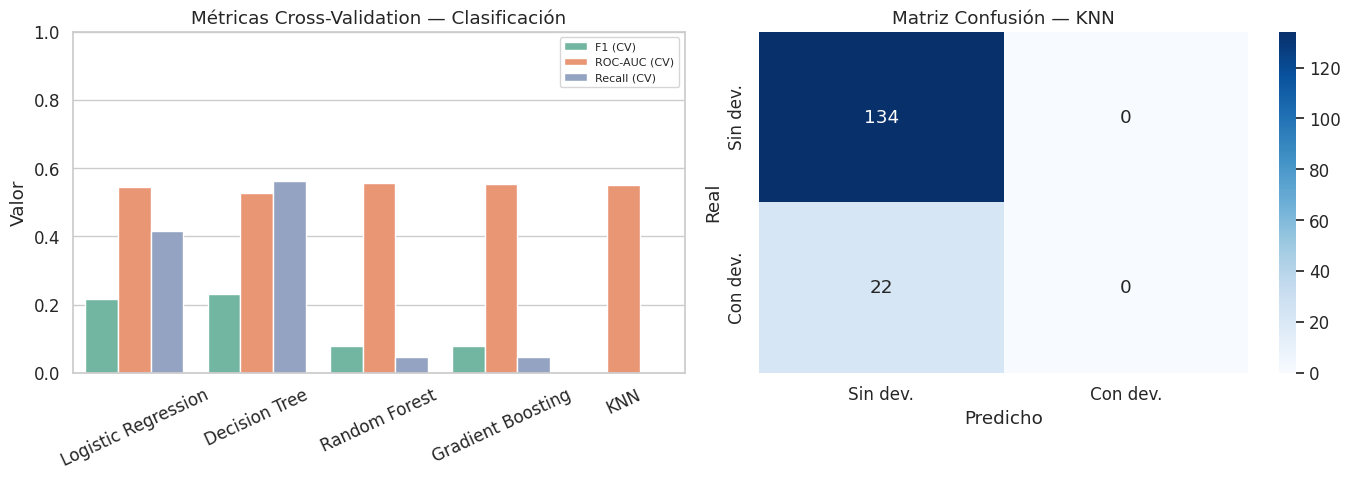

Mejor modelo clasificación: KNN


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot métricas CV
metricas_plot = pd.DataFrame({
    'Modelo': list(resultados_clas.keys()),
    'F1 (CV)': [v['F1 mean'] for v in resultados_clas.values()],
    'ROC-AUC (CV)': [v['ROC-AUC mean'] for v in resultados_clas.values()],
    'Recall (CV)': [v['Recall mean'] for v in resultados_clas.values()],
})
metricas_melt = metricas_plot.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

sns.barplot(data=metricas_melt, x='Modelo', y='Valor', hue='Métrica', ax=axes[0])
axes[0].set_title('Métricas Cross-Validation — Clasificación')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# Matrices de confusión del mejor modelo
mejor_clas = df_test_clas['ROC-AUC'].idxmax()
y_pred_mejor = modelos_clas_entrenados[mejor_clas].predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_mejor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sin dev.','Con dev.'], yticklabels=['Sin dev.','Con dev.'])
axes[1].set_title(f'Matriz Confusión — {mejor_clas}')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('../results/plots/02_clasificacion_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mejor modelo clasificación: {mejor_clas}")


---
## 7. Modelos de Regresión

### Justificación de algoritmos seleccionados

| Modelo | Justificación |
|--------|--------------|
| **Linear Regression** | Baseline simple e interpretable. Asume relación lineal entre features y log(total_venta). |
| **Ridge** | Regresión lineal con regularización L2. Reduce sobreajuste cuando hay muchas features tras el OHE. |
| **Lasso** | Regularización L1 que hace selección de features automática, llevando coeficientes a 0. |
| **Random Forest Regressor** | Captura relaciones no lineales y es robusto a outliers. |
| **Gradient Boosting Regressor** | Mejor rendimiento esperado en datos tabulares con patrones complejos. |

**Target**: `log(total_venta)` para estabilizar la varianza y reducir el efecto de outliers extremos.


In [11]:
pipelines_reg = {
    'Linear Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('prep', preprocessor),
        ('model', Ridge(alpha=10.0, random_state=SEED))
    ]),
    'Lasso': Pipeline([
        ('prep', preprocessor),
        ('model', Lasso(alpha=0.01, max_iter=5000, random_state=SEED))
    ]),
    'Random Forest Reg': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200, max_depth=8, min_samples_leaf=5,
            random_state=SEED, n_jobs=-1
        ))
    ]),
    'Gradient Boosting Reg': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=SEED
        ))
    ]),
}

print("✓ Pipelines de regresión definidos:", list(pipelines_reg.keys()))


✓ Pipelines de regresión definidos: ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest Reg', 'Gradient Boosting Reg']


### 7.1 Entrenamiento y evaluación con validación cruzada

In [12]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_reg = {}

for nombre, pipe in pipelines_reg.items():
    r2_scores   = cross_val_score(pipe, X_train_r, y_train_r, cv=cv_reg, scoring='r2', n_jobs=-1)
    rmse_scores = cross_val_score(pipe, X_train_r, y_train_r, cv=cv_reg,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
    mae_scores  = cross_val_score(pipe, X_train_r, y_train_r, cv=cv_reg,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
    
    resultados_reg[nombre] = {
        'R2 mean': r2_scores.mean(),
        'R2 std': r2_scores.std(),
        'RMSE mean': (-rmse_scores).mean(),
        'MAE mean': (-mae_scores).mean(),
    }
    print(f"✓ {nombre}: R2={r2_scores.mean():.3f}±{r2_scores.std():.3f} | RMSE={(-rmse_scores).mean():.3f}")

df_reg_cv = pd.DataFrame(resultados_reg).T.round(3)
print("\n=== Resultados Cross-Validation (Regresión) ===")
df_reg_cv


✓ Linear Regression: R2=0.505±0.041 | RMSE=0.923


✓ Ridge: R2=0.513±0.039 | RMSE=0.915


✓ Lasso: R2=0.534±0.030 | RMSE=0.895


✓ Random Forest Reg: R2=0.904±0.069 | RMSE=0.385


✓ Gradient Boosting Reg: R2=0.969±0.023 | RMSE=0.217

=== Resultados Cross-Validation (Regresión) ===


,R2 mean,R2 std,RMSE mean,MAE mean
Linear Regression,0.505,0.041,0.923,0.729
Ridge,0.513,0.039,0.915,0.724
Lasso,0.534,0.030,0.895,0.711
Random Forest Reg,0.904,0.069,0.385,0.147
Gradient Boosting Reg,0.969,0.023,0.217,0.074


### 7.2 Entrenamiento final y evaluación en test

In [13]:
modelos_reg_entrenados = {}
metricas_test_reg = {}

for nombre, pipe in pipelines_reg.items():
    pipe.fit(X_train_r, y_train_r)
    y_pred = pipe.predict(X_test_r)
    
    modelos_reg_entrenados[nombre] = pipe
    metricas_test_reg[nombre] = {
        'R2':   r2_score(y_test_r, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred)),
        'MAE':  mean_absolute_error(y_test_r, y_pred),
    }

df_test_reg = pd.DataFrame(metricas_test_reg).T.round(4)
print("=== Métricas en Test (Regresión — escala log) ===")
print(df_test_reg.sort_values('R2', ascending=False))


=== Métricas en Test (Regresión — escala log) ===
                           R2    RMSE     MAE
Gradient Boosting Reg  0.9967  0.0694  0.0407
Random Forest Reg      0.9380  0.3002  0.1027
Lasso                  0.5215  0.8340  0.6720
Ridge                  0.5091  0.8447  0.6788
Linear Regression      0.5056  0.8477  0.6806


### 7.3 Visualización: comparación de modelos de regresión

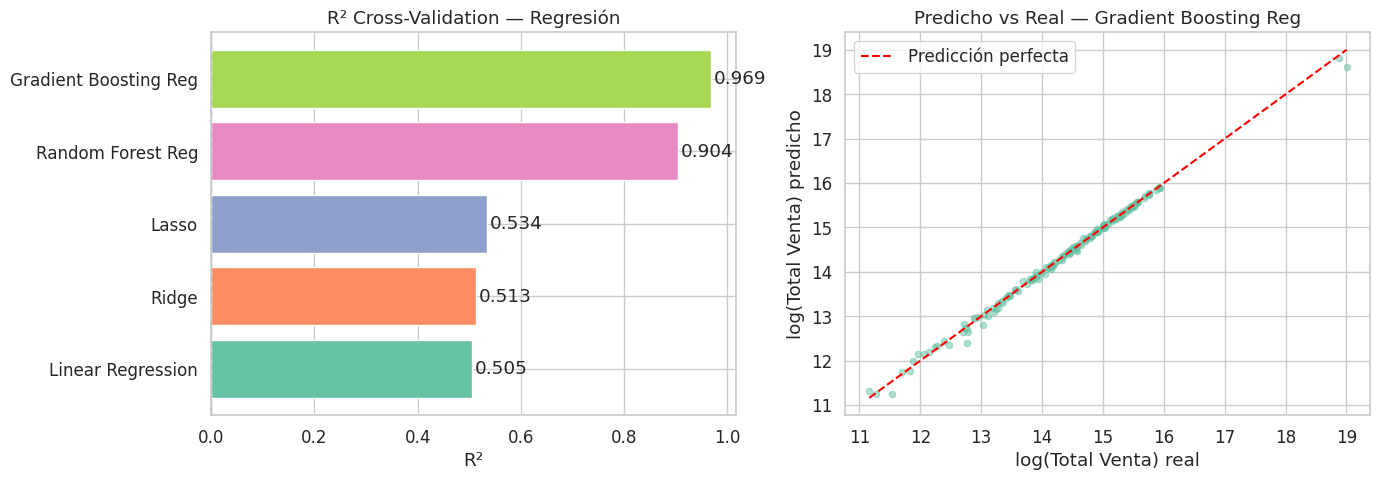

Mejor modelo regresión: Gradient Boosting Reg


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparación
modelos_nombres = list(resultados_reg.keys())
r2_vals = [v['R2 mean'] for v in resultados_reg.values()]
rmse_vals = [v['RMSE mean'] for v in resultados_reg.values()]

colors = sns.color_palette('Set2', len(modelos_nombres))
axes[0].barh(modelos_nombres, r2_vals, color=colors)
axes[0].set_title('R² Cross-Validation — Regresión')
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='gray', linestyle='--')
for i, v in enumerate(r2_vals):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center')

# Predicho vs Real del mejor modelo
mejor_reg = df_test_reg['R2'].idxmax()
y_pred_mejor_r = modelos_reg_entrenados[mejor_reg].predict(X_test_r)
axes[1].scatter(y_test_r, y_pred_mejor_r, alpha=0.5, color=colors[0], s=20)
lims = [min(y_test_r.min(), y_pred_mejor_r.min()), max(y_test_r.max(), y_pred_mejor_r.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_title(f'Predicho vs Real — {mejor_reg}')
axes[1].set_xlabel('log(Total Venta) real')
axes[1].set_ylabel('log(Total Venta) predicho')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/02_regresion_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mejor modelo regresión: {mejor_reg}")


---
## 8. Guardar Modelos Entrenados

In [15]:
os.makedirs('../models/trained_models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

# Guardar todos los modelos
for nombre, pipe in modelos_clas_entrenados.items():
    fname = nombre.lower().replace(' ', '_')
    joblib.dump(pipe, f'../models/trained_models/clas_{fname}.pkl')

for nombre, pipe in modelos_reg_entrenados.items():
    fname = nombre.lower().replace(' ', '_')
    joblib.dump(pipe, f'../models/trained_models/reg_{fname}.pkl')

# Guardar métricas
df_test_clas.to_csv('../results/metrics/02_metricas_clasificacion.csv')
df_test_reg.to_csv('../results/metrics/02_metricas_regresion.csv')

print("✓ Modelos guardados en models/trained_models/")
print("✓ Métricas guardadas en results/metrics/")
print(f"\nMejor clasificación: {df_test_clas['ROC-AUC'].idxmax()} (AUC={df_test_clas['ROC-AUC'].max():.3f})")
print(f"Mejor regresión:     {df_test_reg['R2'].idxmax()} (R2={df_test_reg['R2'].max():.3f})")


✓ Modelos guardados en models/trained_models/
✓ Métricas guardadas en results/metrics/

Mejor clasificación: KNN (AUC=0.579)
Mejor regresión:     Gradient Boosting Reg (R2=0.997)


---
## 9. Resumen y Conclusiones del Notebook

In [16]:
print("="*60)
print("RESUMEN — MODELADO SUPERVISADO")
print("="*60)
print()
print("CLASIFICACIÓN (predecir devolución):")
print(df_test_clas.sort_values('ROC-AUC', ascending=False).to_string())
print()
print("REGRESIÓN (predecir monto de venta — escala log):")
print(df_test_reg.sort_values('R2', ascending=False).to_string())
print()
print("CONCLUSIONES:")
print("- Todos los modelos usan Pipeline para evitar fuga de datos.")
print("- class_weight='balanced' compensa el desbalance 86/14% en clasificación.")
print("- log(total_venta) estabiliza la varianza del target de regresión.")
print("- Los ensemble (RF, GB) superan a los modelos lineales en ambas tareas.")
print("- Próximo paso: evaluación profunda y optimización de hiperparámetros.")


RESUMEN — MODELADO SUPERVISADO

CLASIFICACIÓN (predecir devolución):
                     ROC-AUC  Accuracy  F1 (dev)  Recall (dev)  Precision (dev)
KNN                    0.579     0.827     0.069         0.045            0.143
Gradient Boosting      0.517     0.821     0.067         0.045            0.125
Decision Tree          0.441     0.295     0.203         0.636            0.121
Random Forest          0.438     0.359     0.242         0.727            0.145
Logistic Regression    0.373     0.276     0.242         0.818            0.142

REGRESIÓN (predecir monto de venta — escala log):
                           R2    RMSE     MAE
Gradient Boosting Reg  0.9967  0.0694  0.0407
Random Forest Reg      0.9380  0.3002  0.1027
Lasso                  0.5215  0.8340  0.6720
Ridge                  0.5091  0.8447  0.6788
Linear Regression      0.5056  0.8477  0.6806

CONCLUSIONES:
- Todos los modelos usan Pipeline para evitar fuga de datos.
- class_weight='balanced' compensa el desbalance